# RouteScout — Phase 9
## Final release audit + portfolio packaging

Phase 9 does **not** train, retune or rerun the router.

Its job is to close the evidence chain:

**frozen identities → final results → negative results → claim boundary → reproducible release**

The project is complete when the release tells the same scientific story as the frozen artifacts,
without turning presentation choices into new experiments.

## Executive conclusion

RouteScout found that a simple geometric signal — terminal MST length — is highly effective for
ranking observed PCB routing cost on unseen boards.

The held-out ranking remained strong, a learned residual model improved magnitude estimation, and a
real KiCad-router intervention proved that net order can be controlled. However, the final
hard-first intervention did **not** pass the preregistered routability-benefit gate.

That combination is the final result: **strong prediction, no clear ordering benefit**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

phase_status = pd.DataFrame([
    ("1","Data integrity","FROZEN"),
    ("2","Label + features","FROZEN"),
    ("3","Simple baselines","FROZEN"),
    ("4","Leakage-safe split","FROZEN"),
    ("5","Model development","FROZEN"),
    ("6","Champion lock","FROZEN"),
    ("7","Held-out test","FROZEN"),
    ("8A","Router mechanism","FROZEN — PASS"),
    ("8B","Real intervention","FROZEN — NO CLEAR BENEFIT"),
    ("9","Release audit","FINAL"),
], columns=["phase","purpose","status"])
phase_status

,phase,purpose,status
0,1,Data integrity,FROZEN
1,2,Label + features,FROZEN
2,3,Simple baselines,FROZEN
3,4,Leakage-safe split,FROZEN
4,5,Model development,FROZEN
5,6,Champion lock,FROZEN
6,7,Held-out test,FROZEN
7,8A,Router mechanism,FROZEN — PASS
8,8B,Real intervention,FROZEN — NO CLEAR BENEFIT
9,9,Release audit,FINAL


## Dataset and evaluation contract

- 1,182 audited PCBench boards
- 1,121 Phase-2 eligible boards
- 47,051 supervised candidate nets
- label: `log1p(observed routed wire length)`
- family / duplicate / near-duplicate-aware split
- 785 train boards, 168 validation boards, 168 test boards
- test opened exactly once after the final ranking rule was locked

The target is **Observed Routed Cost**, not intrinsic physical difficulty.

## Held-out ranking

Final ranking model: **MST-only**

- Mean board-wise Spearman: **0.92402**
- Top-5 cost capture: **0.98099**
- Top-5 overlap: **0.84286**
- NDCG@5: **0.98075**
- R²: **0.96681**

The result is weaker than validation, as expected on a genuinely unseen test set, but the ranking
signal remains strong.

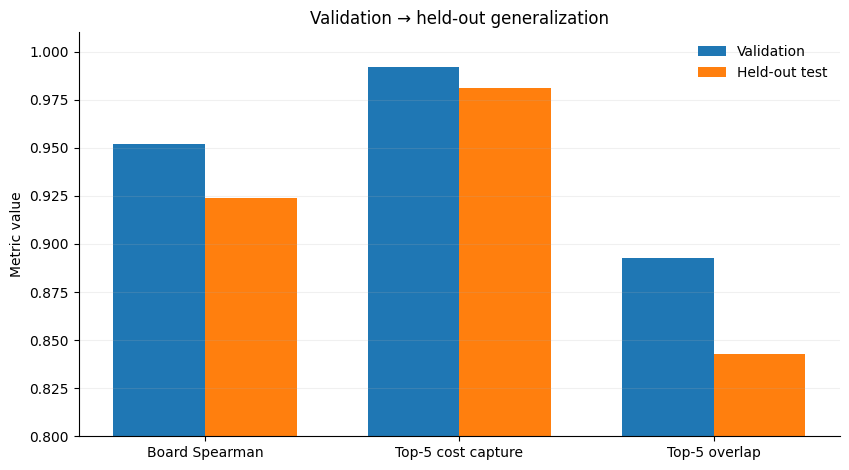

In [2]:
metrics=["Board Spearman","Top-5 cost capture","Top-5 overlap"]
validation=[0.9517655,0.9919887,0.8925]
heldout=[0.9240179379260456,0.9809876927692095,0.8428571428571427]
x=np.arange(len(metrics)); w=0.36
fig,ax=plt.subplots(figsize=(8.6,4.8))
ax.bar(x-w/2,validation,w,label="Validation")
ax.bar(x+w/2,heldout,w,label="Held-out test")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(.80,1.01)
ax.set_ylabel("Metric value")
ax.set_title("Validation → held-out generalization")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y",alpha=.18)
plt.tight_layout()
plt.show()

## Magnitude estimation

The frozen secondary model — **CatBoost residual + relational** — reduced held-out log-MAE from
**0.14167** to **0.12468**, about **12%**.

This is a magnitude-estimation result. It does not retroactively replace the preregistered
MST-only ranking champion.

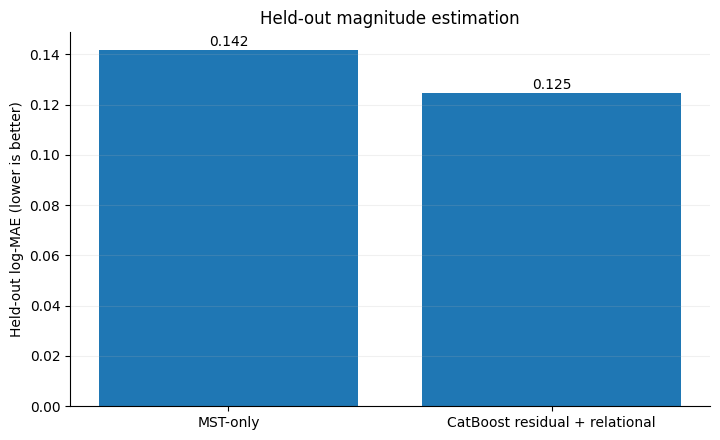

In [3]:
models=["MST-only","CatBoost residual + relational"]
mae=[0.1416659671644751,0.12468492613978792]
fig,ax=plt.subplots(figsize=(7.3,4.5))
bars=ax.bar(models,mae)
ax.set_ylabel("Held-out log-MAE (lower is better)")
ax.set_title("Held-out magnitude estimation")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y",alpha=.18)
for b,v in zip(bars,mae):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+.0015,f"{v:.3f}",ha="center")
plt.tight_layout()
plt.show()

## Why no GNN?

The project had a graph hypothesis, but graph complexity had an admission gate.

Relational tabular features did not improve the main ranking objective enough to justify a GNN.
The correct outcome was therefore:

`GNN_BLOCKED_NO_RELATIONAL_SIGNAL`

This keeps model complexity proportional to evidence.

## Phase 8 — prediction versus engineering benefit

Phase 8A first established that the pinned KiCad PNS router could be run under deliberately
different explicit net-selection orders while the within-net routine stayed fixed.

Phase 8B then ran the real-board intervention on **24 valid boards / 72 policy runs**, with
**0 API errors** and **72/72 exact issued orders**.

Primary result, MST-hard-first minus natural:

- mean target-routability delta: **+0.01290**
- 95% paired-bootstrap CI: **[0.00000, 0.03177]**
- whole-board DRC-error delta: **−0.08333**
- DRC CI: **[−0.20833, 0.00000]**

The benefit gate required a routability lower bound strictly above zero. The lower bound was zero.

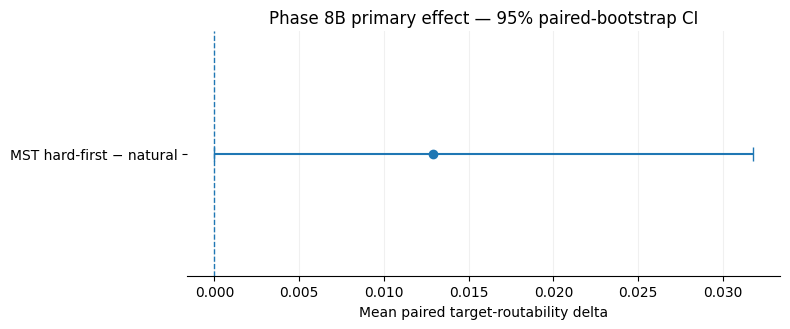

In [4]:
mean=0.012896825397; lo=0.0; hi=0.031770833333
fig,ax=plt.subplots(figsize=(8.0,3.4))
ax.axvline(0,linestyle="--",linewidth=1)
ax.errorbar([mean],[0],xerr=[[mean-lo],[hi-mean]],fmt="o",capsize=5)
ax.set_yticks([0]); ax.set_yticklabels(["MST hard-first − natural"])
ax.set_xlabel("Mean paired target-routability delta")
ax.set_title("Phase 8B primary effect — 95% paired-bootstrap CI")
ax.spines[["top","right","left"]].set_visible(False)
ax.grid(axis="x",alpha=.18)
plt.tight_layout()
plt.show()

## Final claim boundary

### Supported

- Pre-routing terminal geometry strongly ranks observed routed cost on unseen PCB designs.
- CatBoost improves held-out magnitude estimation.
- Explicit net-order intervention is technically controllable in the pinned router.

### Not supported

- GNN superiority.
- A clear hard-first routability benefit.
- Treating routed length as intrinsic ground-truth difficulty.
- Per-net via-count supervision in the audited conversion.

## Final status

`ROUTESCOUT_V1_0_FINAL_RELEASE_FROZEN`

No further model selection is allowed on the consumed held-out test.